In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


In [28]:
df = pd.read_csv('data/stud.csv')

In [29]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [32]:
df.shape


(1000, 8)

In [33]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [39]:
df.nunique()


gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [40]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Exploring data

In [41]:
print("Categories in 'gender' variable:   ",end= " ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable:   ",end= " ")
print(df['race/ethnicity'].unique())


print("Categories in ' parental level of education ' variable:   ",end= " ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:   ",end= " ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:   ",end= " ")
print(df['test preparation course'].unique())

Categories in 'gender' variable:    <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable:    <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in ' parental level of education ' variable:    <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:    <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:    <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [44]:
# define numerical and categorical columns
numeric_features=[feature for feature in df.columns if df[feature].dtypes == 'int64']
categorical_features=[feature for feature in df.columns if df[feature].dtypes != 'int64']

print('We have {} numerical features : {}'.format(len(numeric_features),numeric_features))
print('We have {} categorical features : {}'.format(len(categorical_features),categorical_features))

We have 3 numerical features : ['math score', 'reading score', 'writing score']
We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


Adding columns for total score and average

In [45]:
df['total score']=df['math score']+df['reading score']+df['writing score']
df['average']=df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [49]:
reading_full = df[df['reading score']==100]['average'].count()
math_full = df[df['math score']==100]['average'].count()
writing_full = df[df['writing score']==100]['average'].count()

print(f'Number of students with full marks in maths:{math_full}')
print(f'Number of students with full marks in reading:{reading_full}')
print(f'Number of students with full marks in writing:{writing_full}')


Number of students with full marks in maths:7
Number of students with full marks in reading:17
Number of students with full marks in writing:14


students are doing worst in maths and good in reading

In [51]:
reading_less_20=df[df['reading score'] <=20 ]['average'].count()
writing_less_20=df[df['writing score'] <=20 ]['average'].count()
math_less_20=df[df['math score'] <=20 ]['average'].count()


print(f'Number of students with less than 20 marks in Maths:{math_less_20}')
print(f'Number of students with less than 20 marks in reading:{reading_less_20}')
print(f'Number of students with less than 20 marks in writing:{writing_less_20}')


Number of students with less than 20 marks in Maths:4
Number of students with less than 20 marks in reading:1
Number of students with less than 20 marks in writing:3


Visualisation

visualize average score distribution


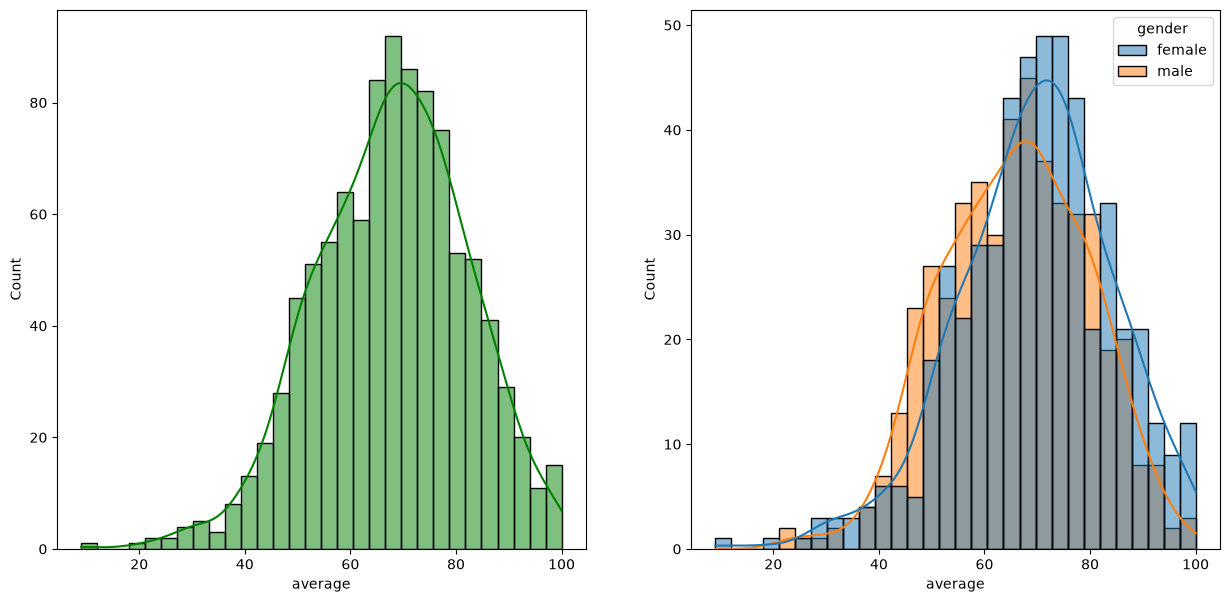

In [52]:
fig , axis = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='gender')
plt.show()


insight:female tend to perform relatively well

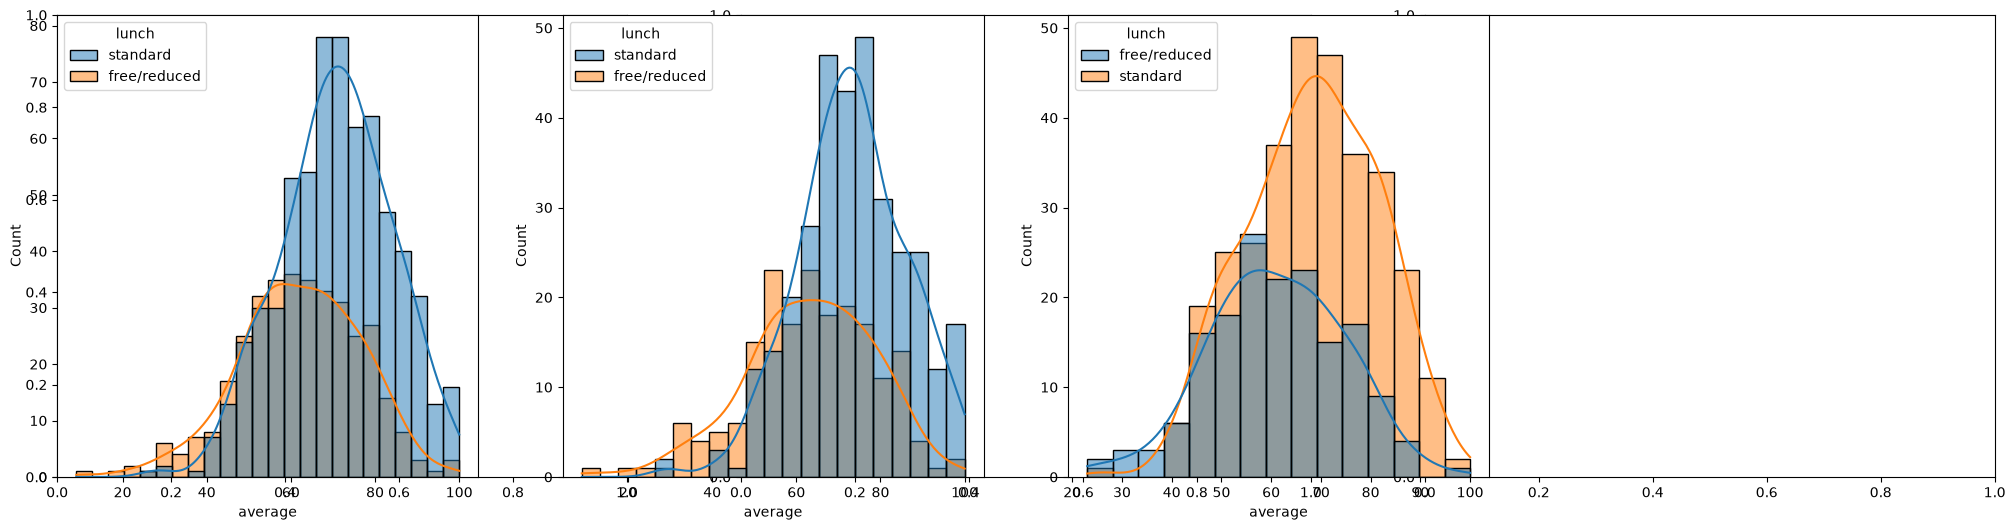

In [53]:
fig , axis = plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()


insights:
1.std lunch help to perform well in exams for be it male or female

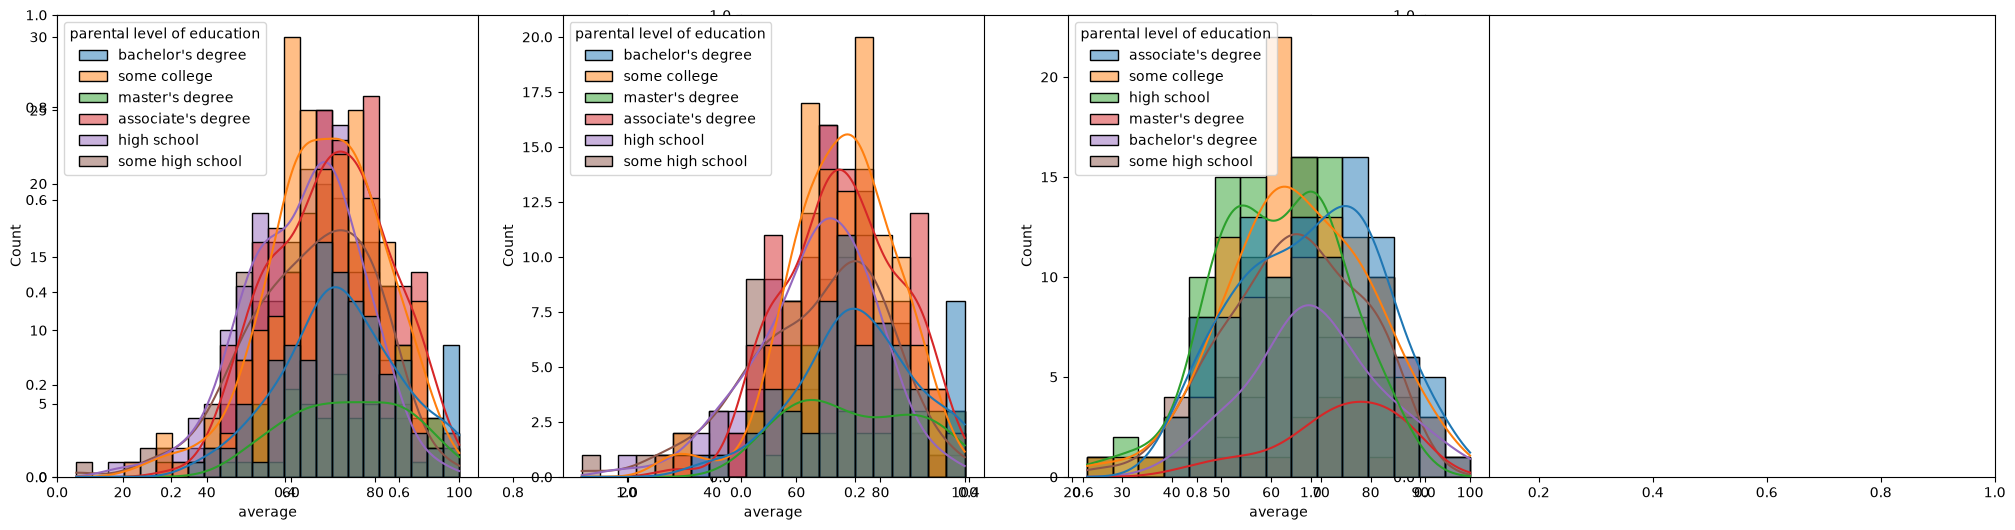

In [54]:
fig , axis = plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='parental level of education')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental level of education')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental level of education')
plt.show()


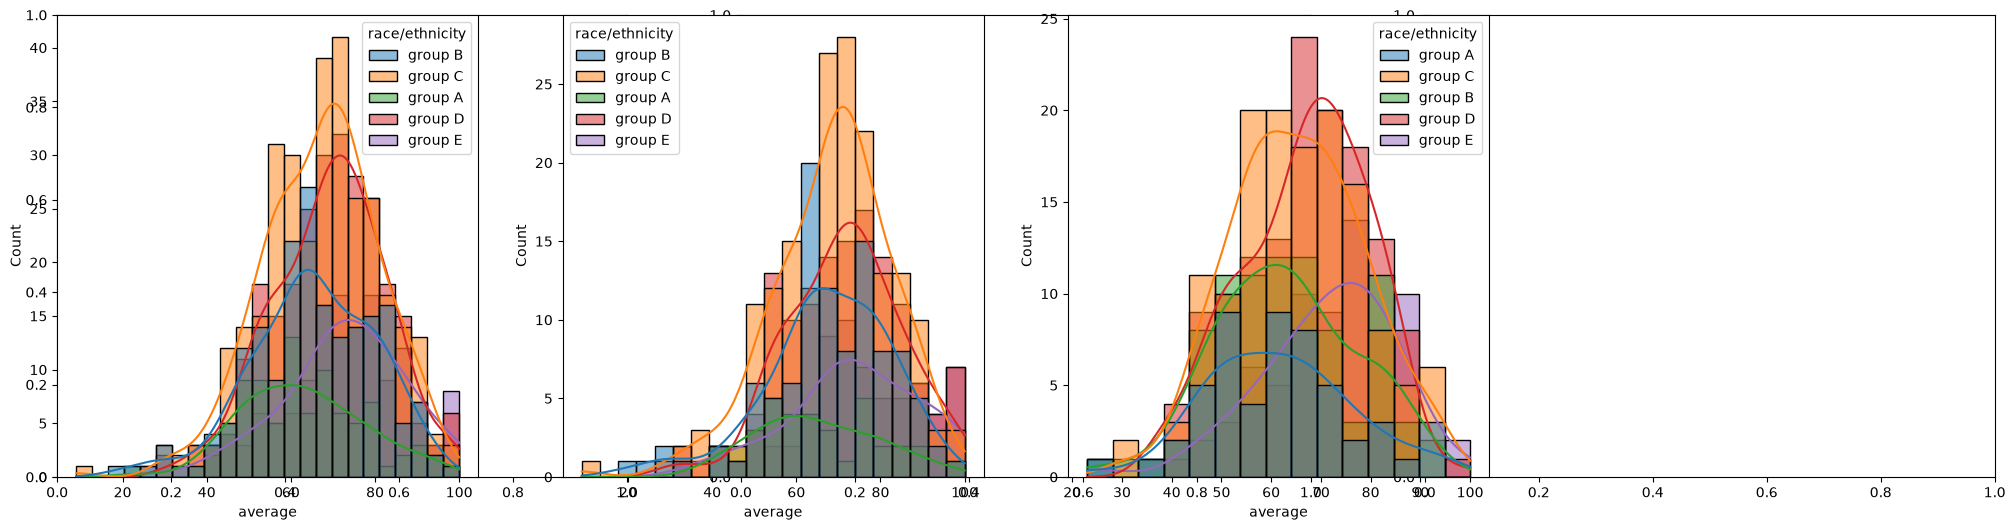

In [55]:
fig , axis = plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='race/ethnicity')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race/ethnicity')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race/ethnicity')
plt.show()


Maximun score of stundents in all three subjects

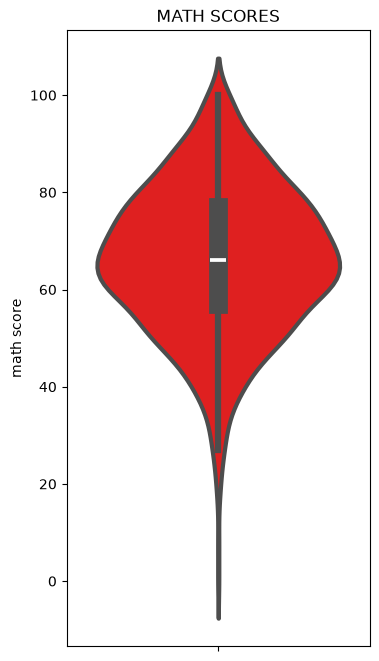

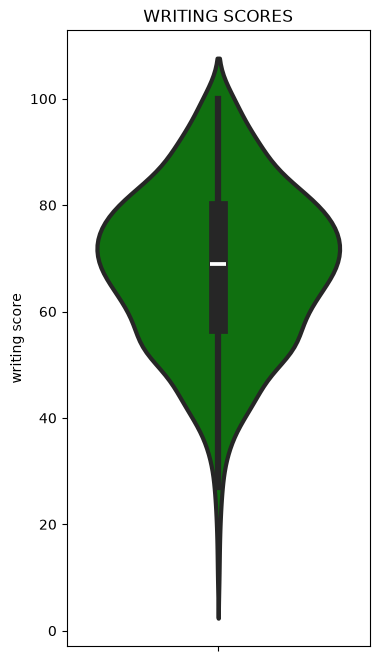

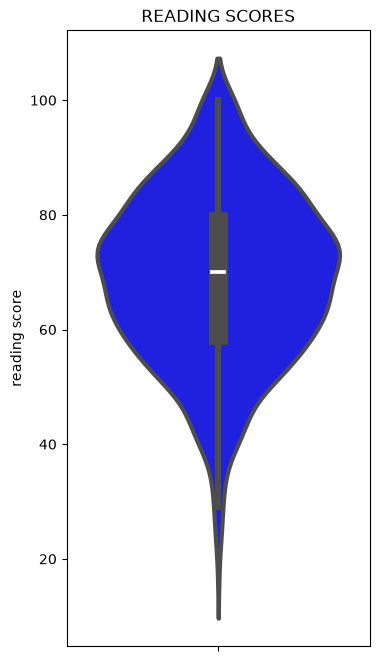

In [56]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('MATH SCORES')
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.figure(figsize=(18,8))
plt.subplot(1,4,2)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score',data=df,color='green',linewidth=3)
plt.figure(figsize=(18,8))
plt.subplot(1,4,3)
plt.title('READING SCORES')
sns.violinplot(y='reading score',data=df,color='blue',linewidth=3)
plt.show()

In [58]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


Insights: students mostly perfrom in between 60-80 marks in maths and 50-80 in reading and writing.

Mulitvariate analysis using pieplot

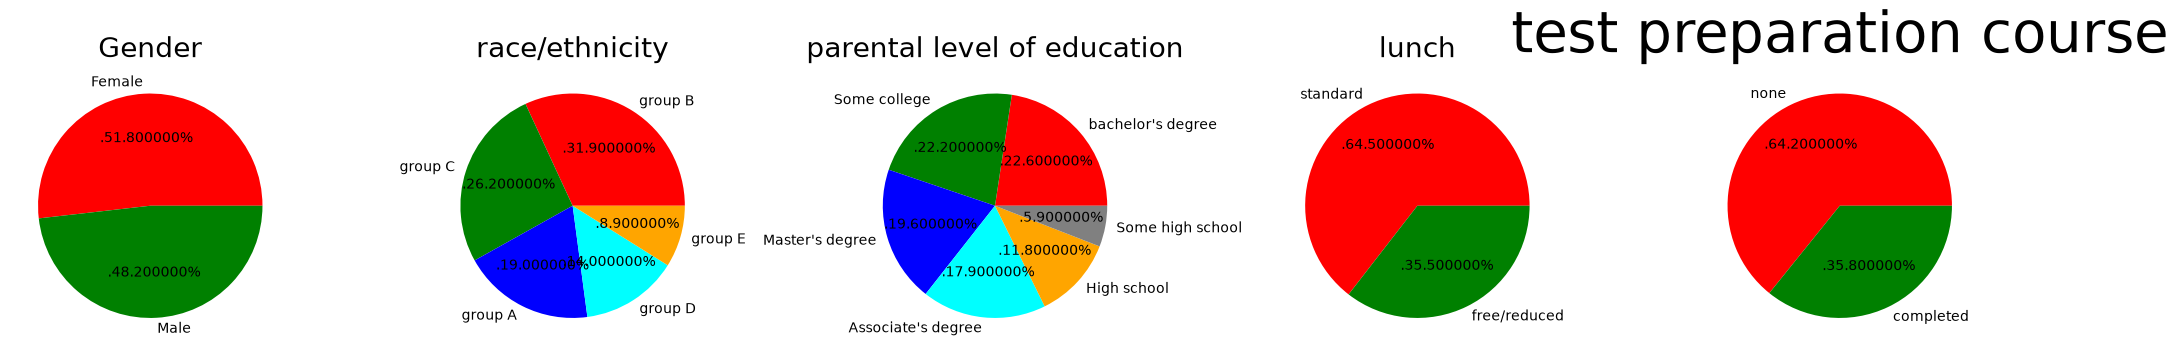

In [64]:
plt.rcParams['figure.figsize']=(20,20)

plt.subplot(1,5,1)
size=df['gender'].value_counts()
labels='Female','Male'
color=['red','green']

plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('Gender',fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size=df['race/ethnicity'].value_counts()
labels='group B', 'group C', 'group A', 'group D', 'group E'
color=['red','green','blue','cyan','orange']

plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('race/ethnicity',fontsize=20)
plt.axis('off')



plt.subplot(1,5,3)
size=df['parental level of education'].value_counts()
labels="bachelor's degree","Some college","Master's degree","Associate's degree","High school","Some high school"
color=['red','green','blue','cyan','orange','grey']

plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('parental level of education',fontsize=20)
plt.axis('off')



plt.subplot(1,5,4)
size=df['lunch'].value_counts()
labels='standard', 'free/reduced'
color=['red','green']

plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('lunch',fontsize=20)
plt.axis('off')


plt.subplot(1,5,5)
size=df['test preparation course'].value_counts()
labels='none', 'completed'
color=['red','green']

plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('test preparation course',fontsize=40)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()



Feature wise visualization

Gender column

how is distribution of gender?
does gender have any impact on student's performance ?

UNIVARIATE ANALYSIS ( HOW IS DISTRIBUTION OF GENDER?)




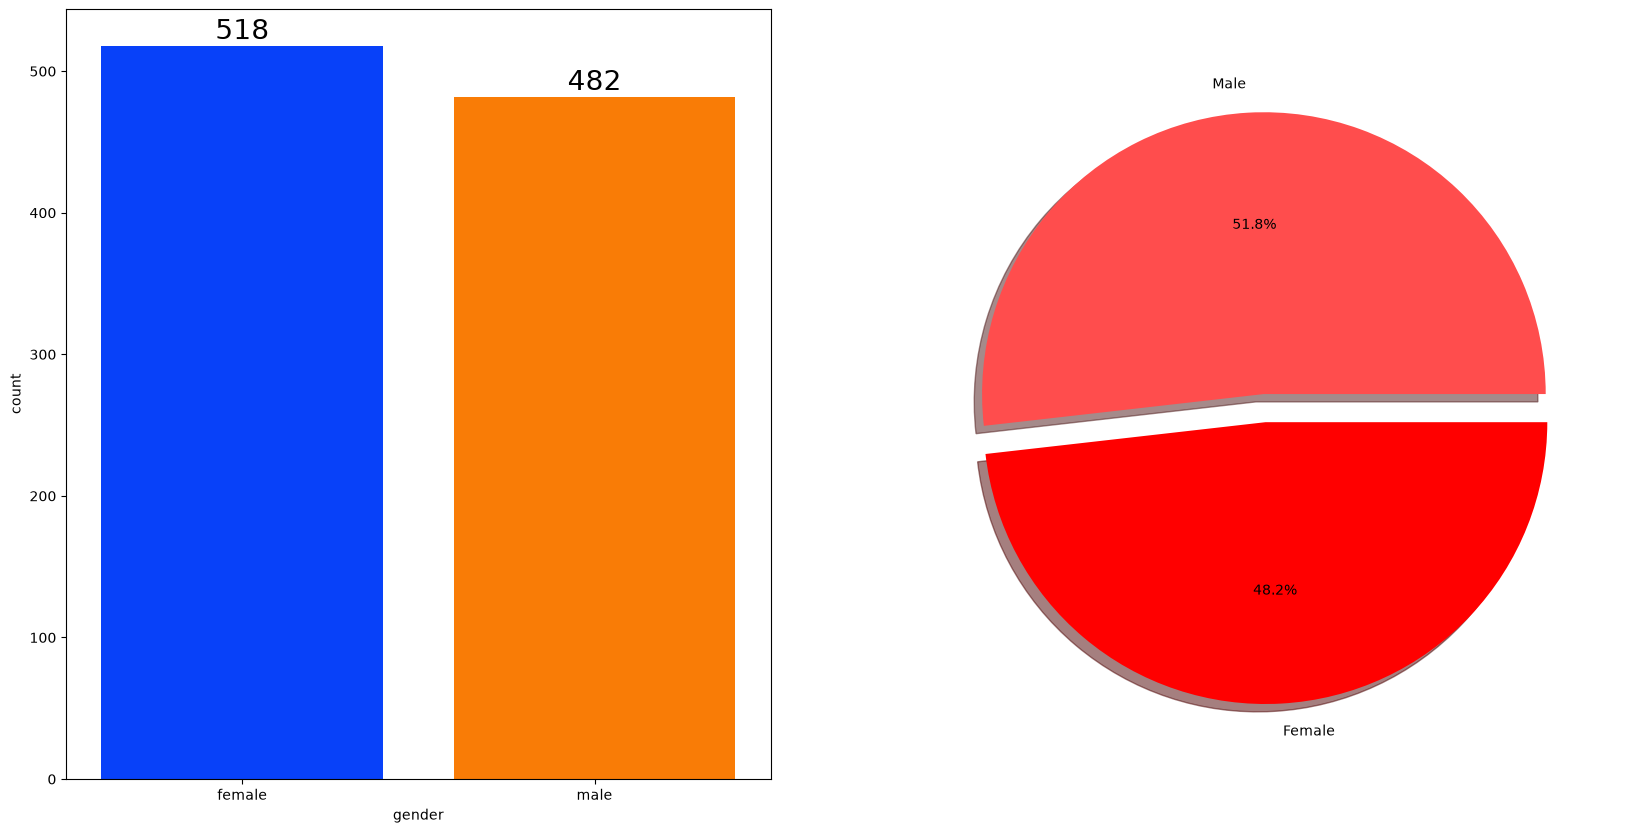

In [69]:
f,ax =plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','red'])   
plt.show() 

BIVARATE ANALYSIS(DOES GENDER HAVE ANY IMPACT ON STUDENTS'S PERFORMANCE)

In [71]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


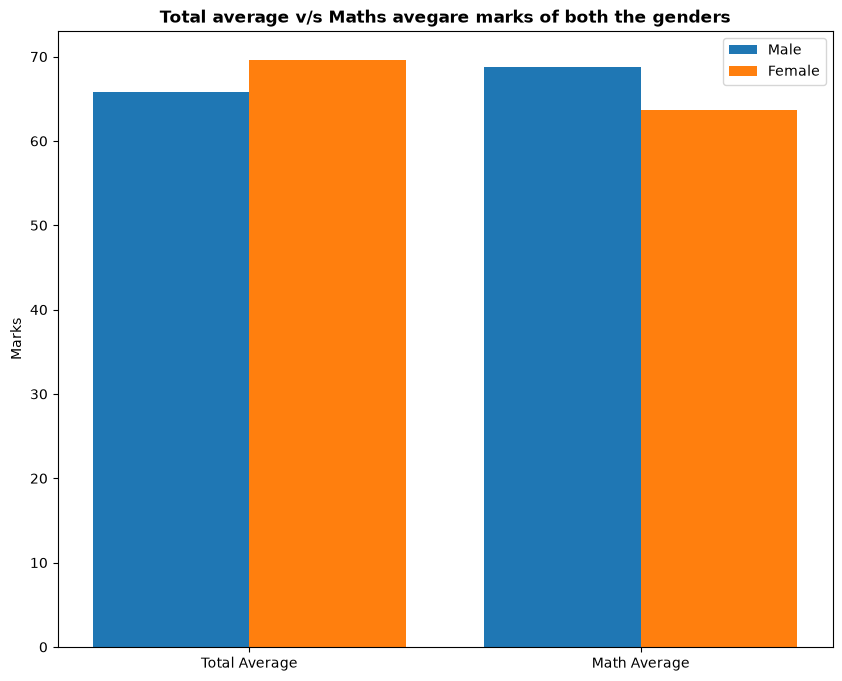

In [78]:
plt.figure(figsize=(10,8))

X = ['Total Average','Math Average']

female_score = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math score']
]

male_score = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math score']
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_score,0.4,label = 'Male')
plt.bar(X_axis + 0.2, female_score,0.4,label = 'Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Maths avegare marks of both the genders",fontweight='bold')
plt.legend()
plt.show()

UNIVERATE ANALYSIS (HOW IS GROUP WISE DISRIBUTION?)


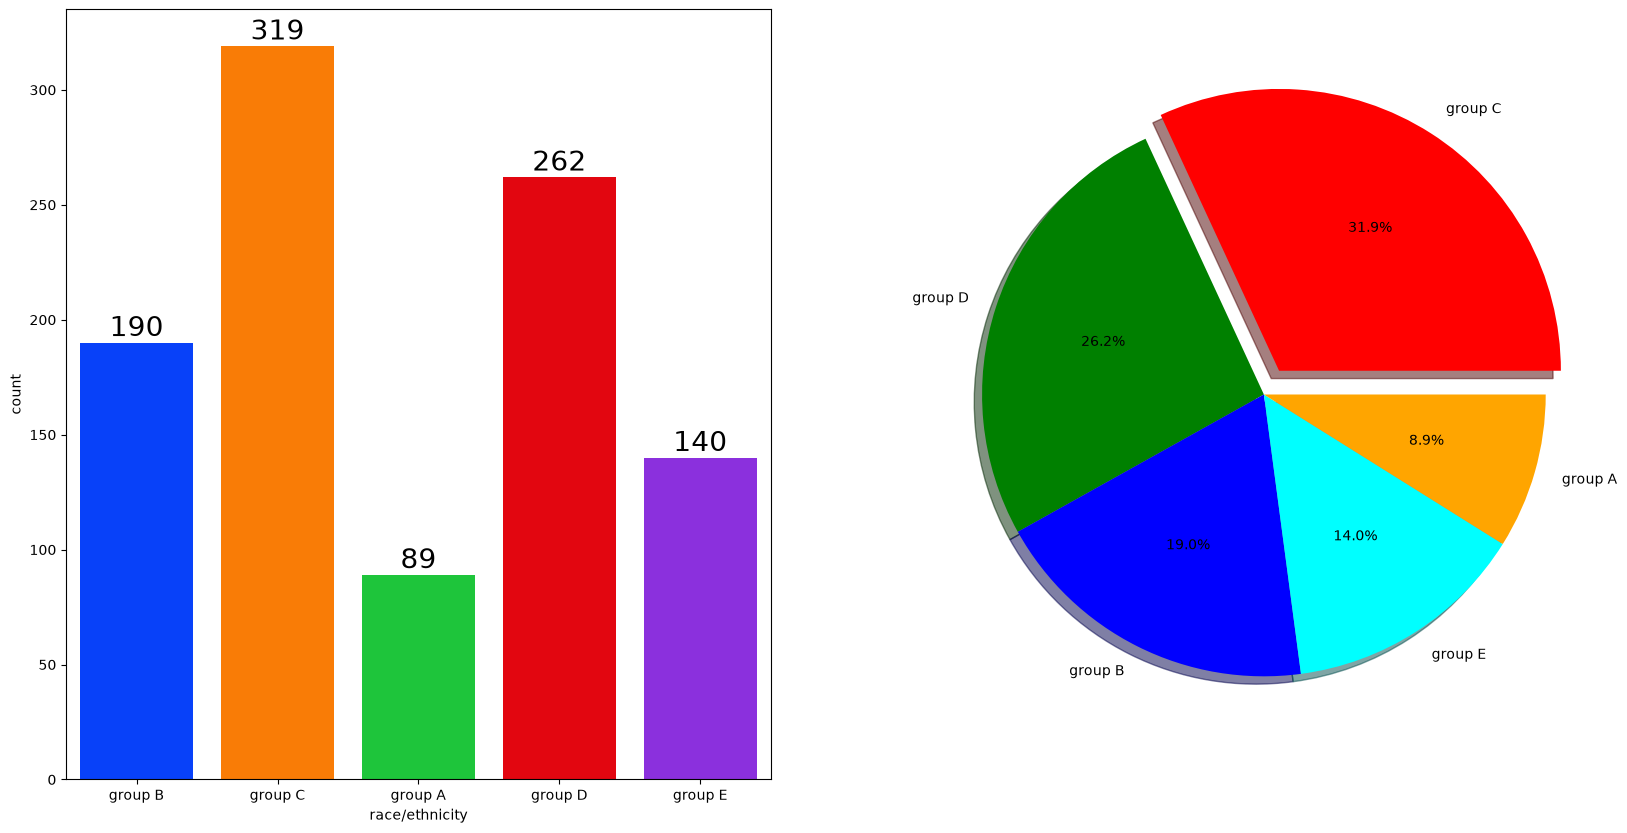

In [80]:
f,ax =plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True,colors=['red','green','blue','cyan','orange'])   
plt.show() 

Bivarate analysis (is race a factor in student's perforance?)



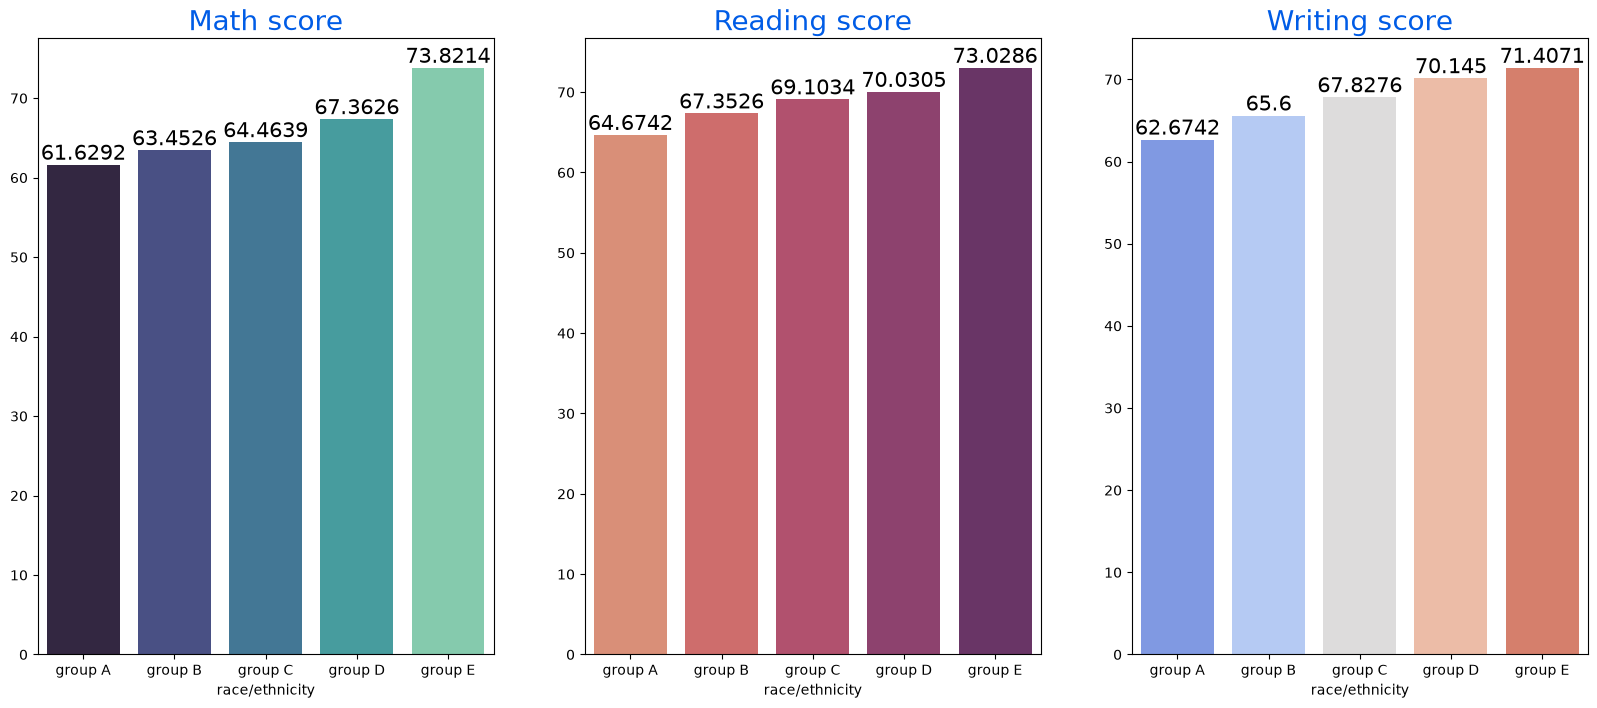

In [81]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )


findfont: Failed to find font weight 30, now using 400.


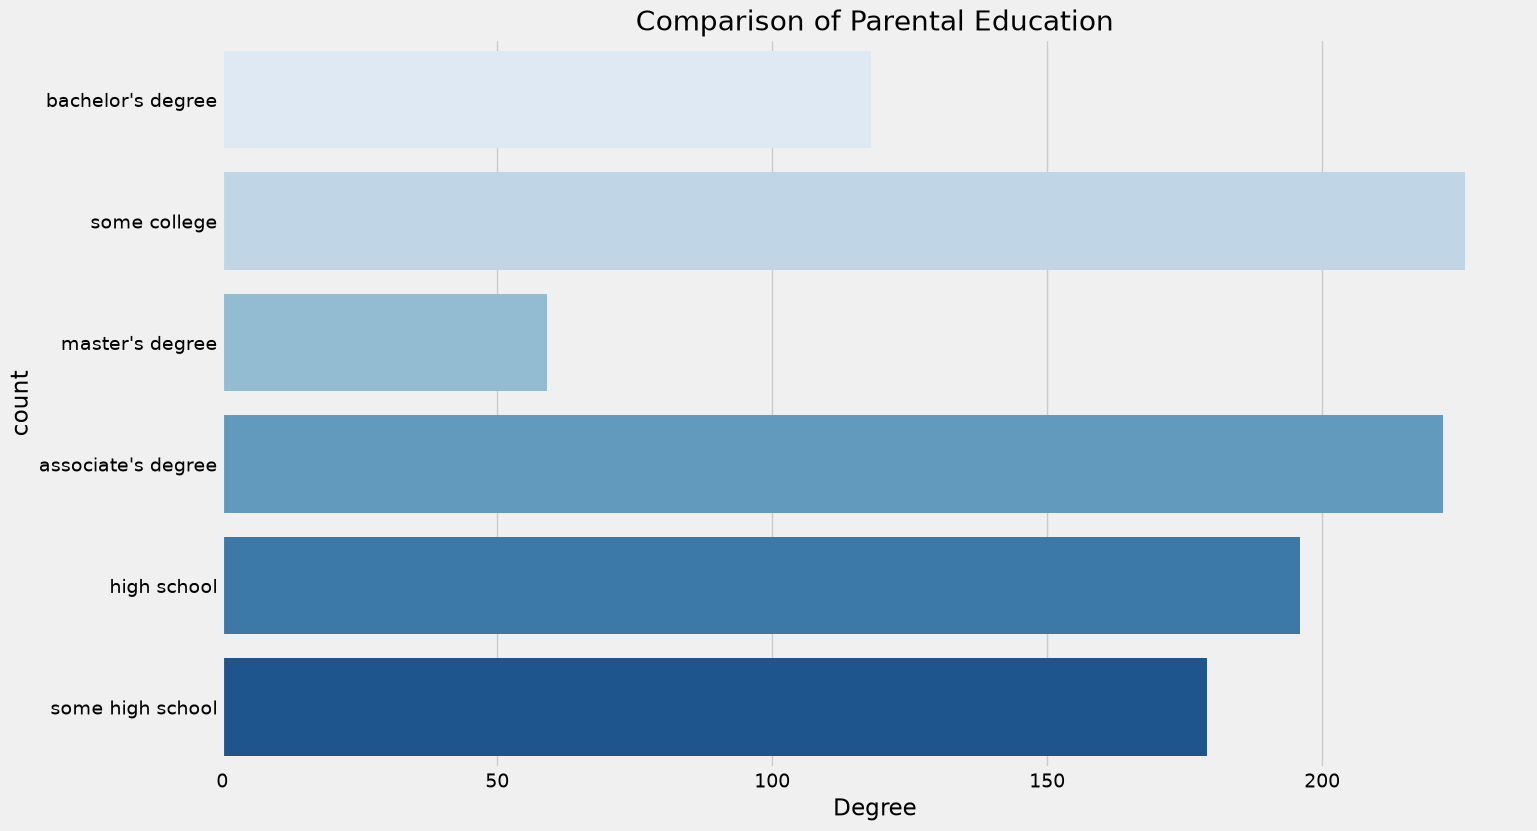

In [82]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

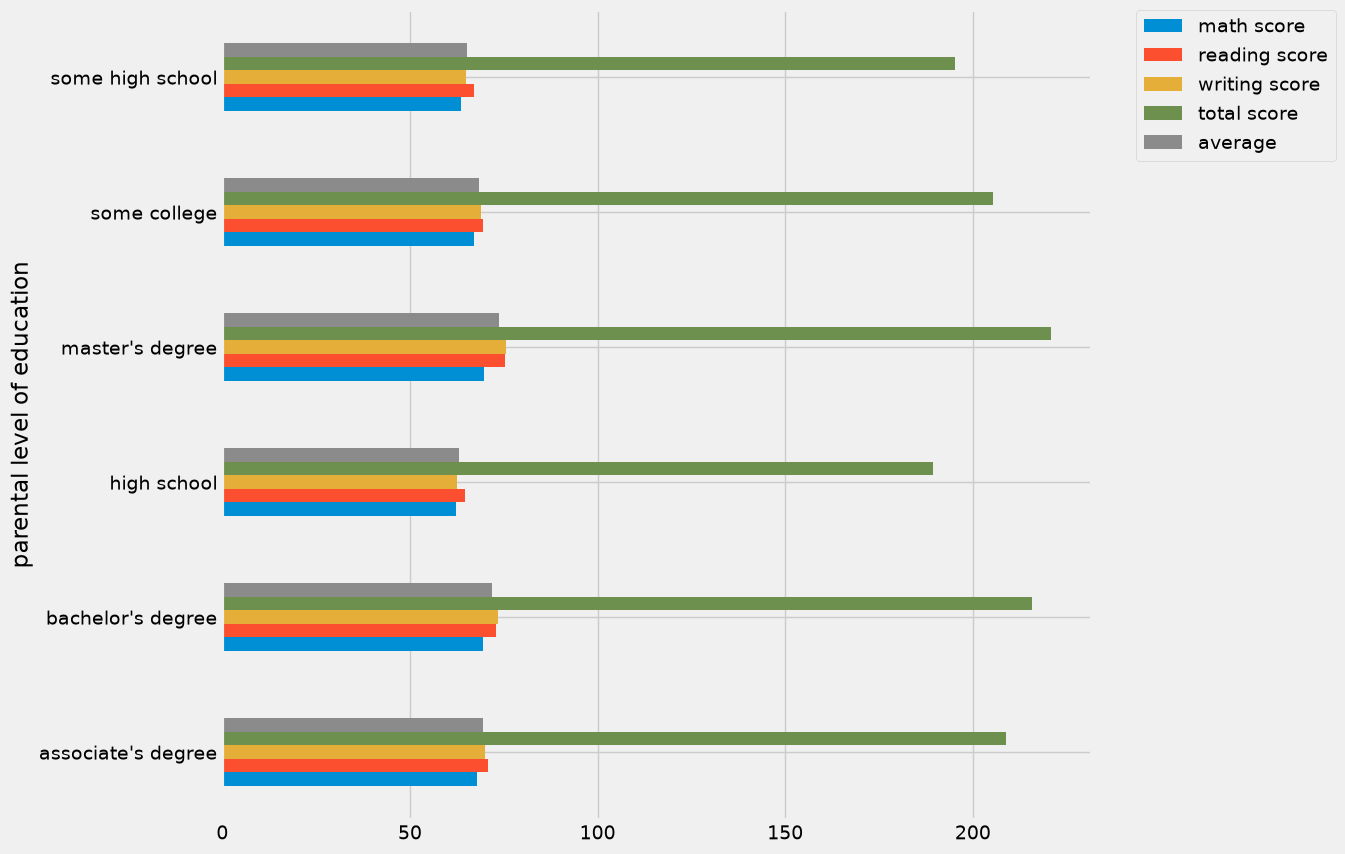

In [85]:
df.groupby('parental level of education').mean(numeric_only=True).plot(kind='barh', figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

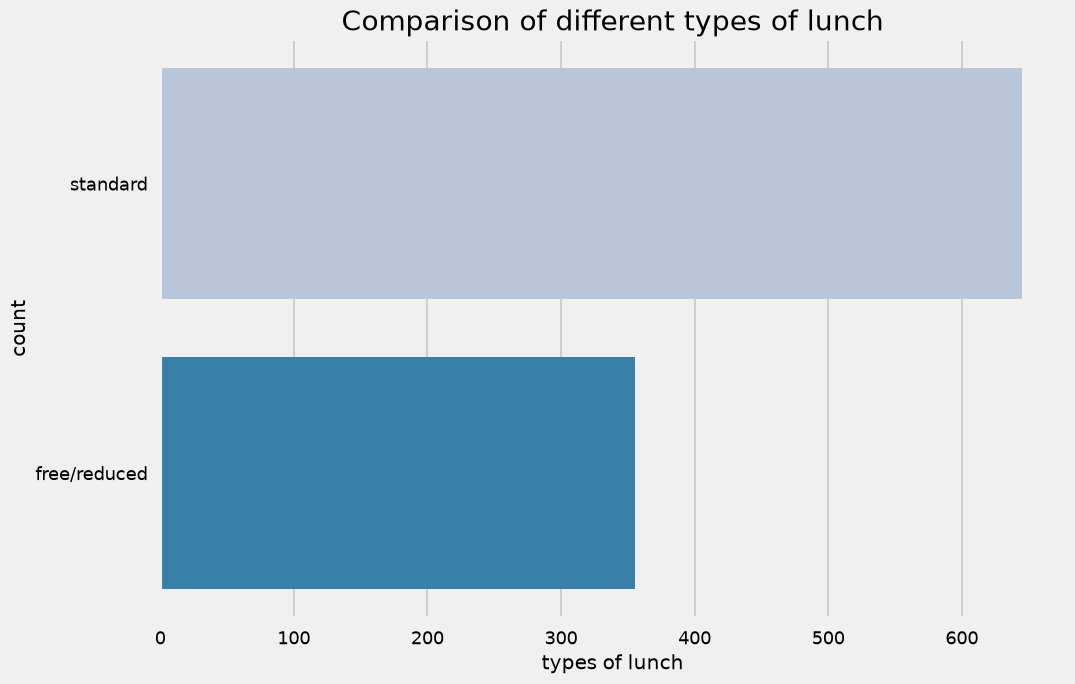

In [87]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

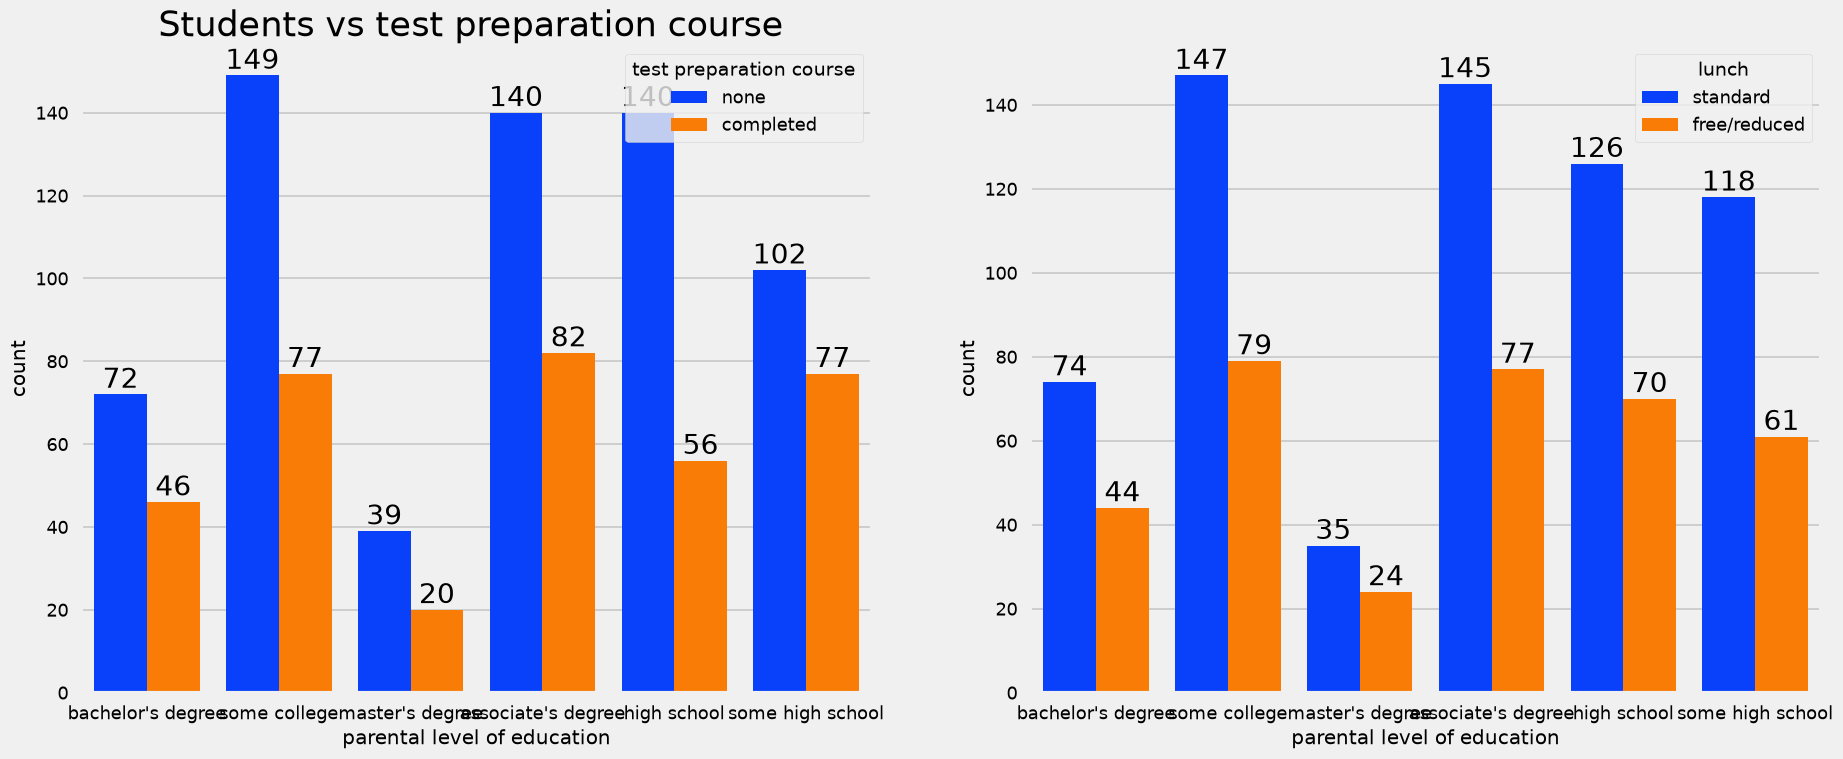

In [88]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='test preparation course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing score'>

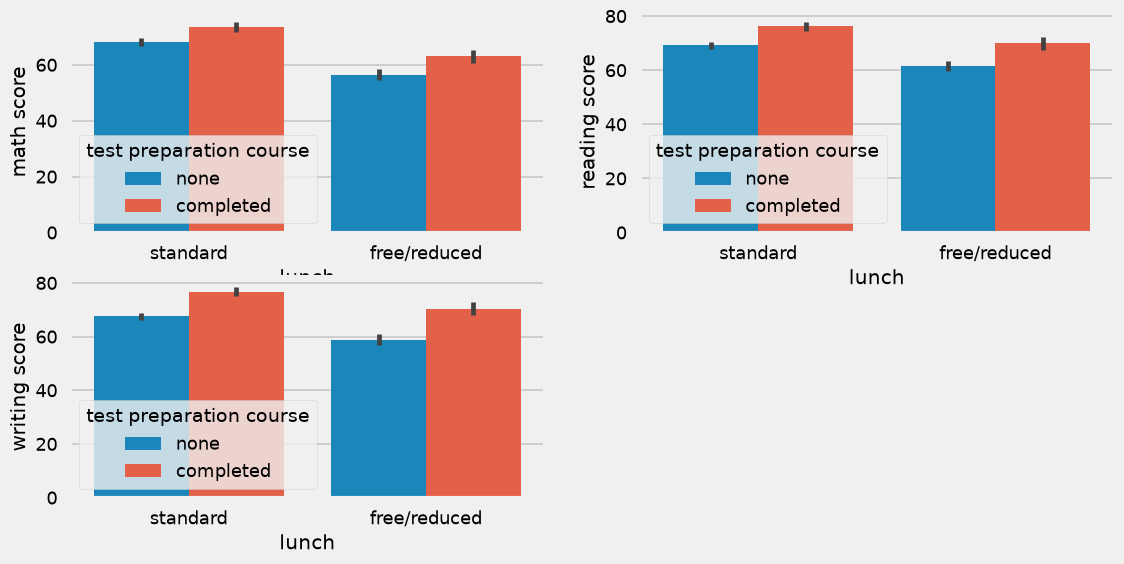

In [89]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])

#### 4.4.6 CHECKING OUTLIERS

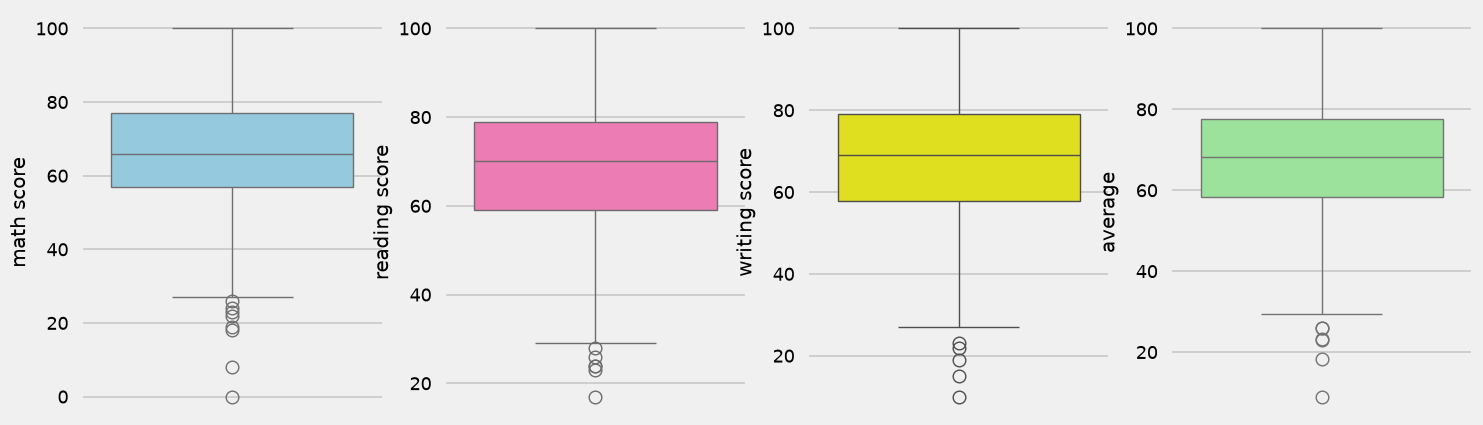

In [90]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

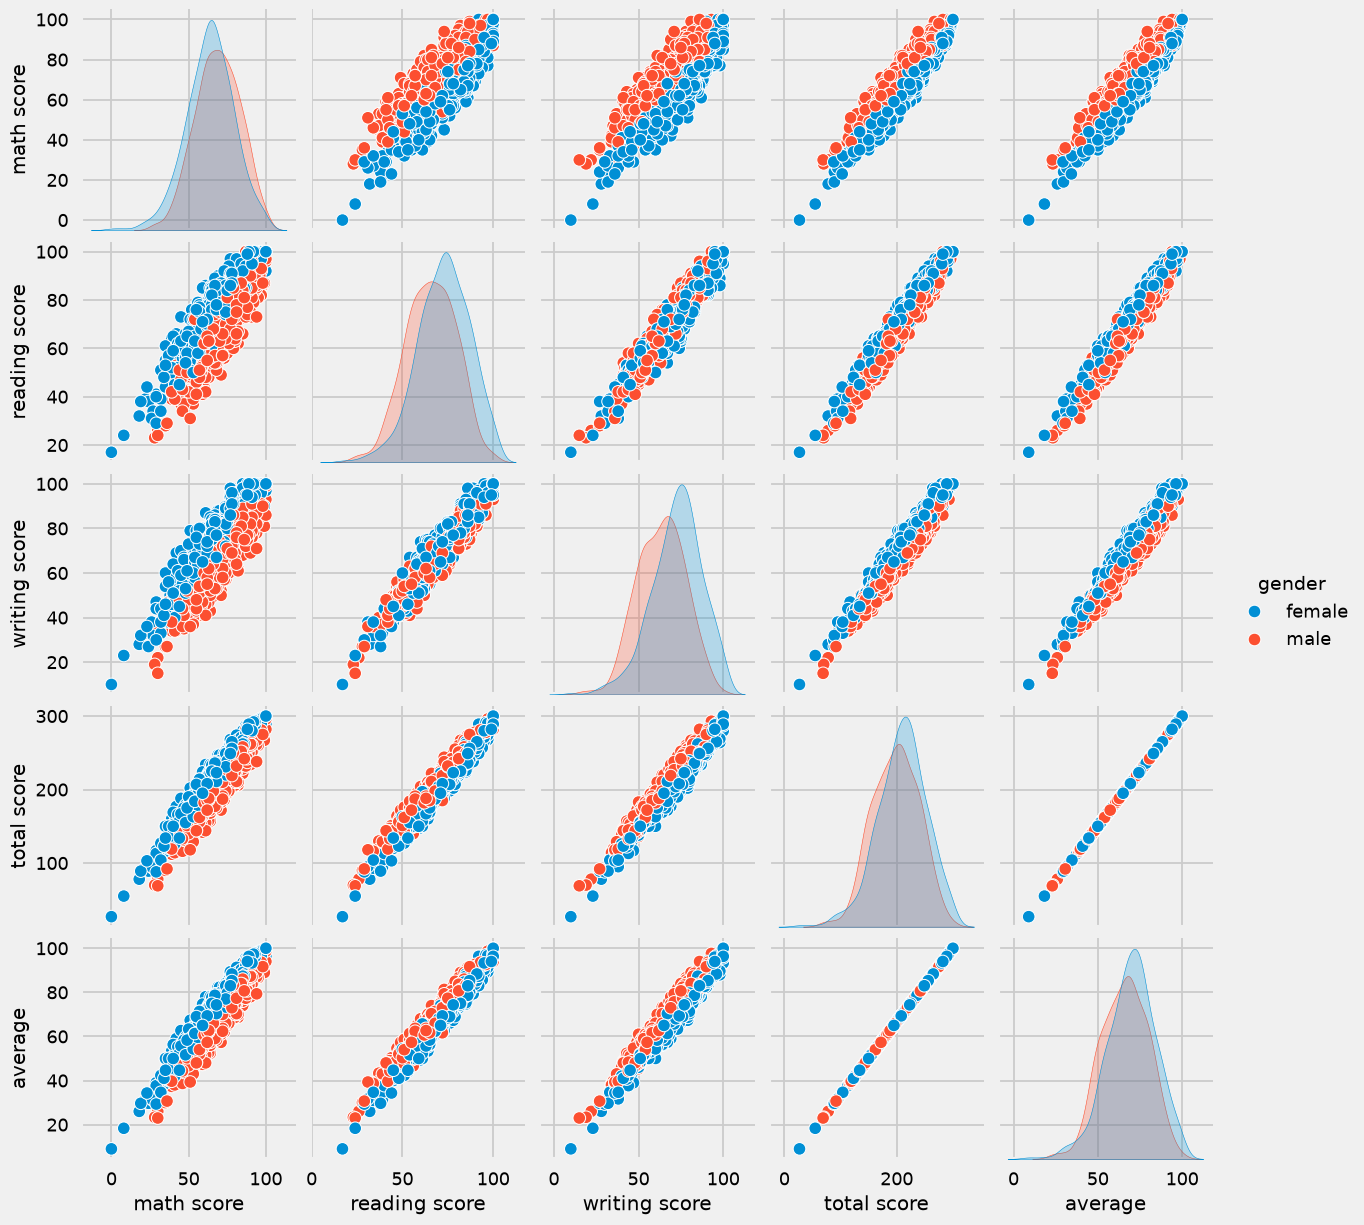

In [91]:
sns.pairplot(df,hue = 'gender')
plt.show()


#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.